In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

Load datasets

In [2]:
df_matches = pd.read_csv('matches.csv')
df_deliveries = pd.read_csv('deliveries.csv')

print(df_matches.shape)
df_matches.head()

(1095, 20)


,id,season,city,date,match_type,player_of_match,venue,team1,team2,toss_winner,toss_decision,winner,result,result_margin,target_runs,target_overs,super_over,method,umpire1,umpire2
0,335982,2007/08,Bangalore,2008-04-18,League,BB McCullum,M Chinnaswamy Stadium,Royal Challengers Bangalore,Kolkata Knight Riders,Royal Challengers Bangalore,field,Kolkata Knight Riders,runs,140.0,223.0,20.0,N,NaN,Asad Rauf,RE Koertzen
1,335983,2007/08,Chandigarh,2008-04-19,League,MEK Hussey,"Punjab Cricket Association Stadium, Mohali",Kings XI Punjab,Chennai Super Kings,Chennai Super Kings,bat,Chennai Super Kings,runs,33.0,241.0,20.0,N,NaN,MR Benson,SL Shastri
2,335984,2007/08,Delhi,2008-04-19,League,MF Maharoof,Feroz Shah Kotla,Delhi Daredevils,Rajasthan Royals,Rajasthan Royals,bat,Delhi Daredevils,wickets,9.0,130.0,20.0,N,NaN,Aleem Dar,GA Pratapkumar
3,335985,2007/08,Mumbai,2008-04-20,League,MV Boucher,Wankhede Stadium,Mumbai Indians,Royal Challengers Bangalore,Mumbai Indians,bat,Royal Challengers Bangalore,wickets,5.0,166.0,20.0,N,NaN,SJ Davis,DJ Harper
4,335986,2007/08,Kolkata,2008-04-20,League,DJ Hussey,Eden Gardens,Kolkata Knight Riders,Deccan Chargers,Deccan Chargers,bat,Kolkata Knight Riders,wickets,5.0,111.0,20.0,N,NaN,BF Bowden,K Hariharan


Cleaning

In [3]:
# Drop unnecessary columns
df_matches = df_matches.drop(columns=[
    'id','date','player_of_match','result','result_margin',
    'method','umpire1','umpire2','target_runs','target_overs'
])

# Remove rows where winner is missing
df_matches = df_matches[df_matches['winner'].notna()]

# Fill missing city
df_matches['city'] = df_matches['city'].fillna('Unknown')

Mapping Team Names from same franchise

In [4]:
team_mapping = {
    'Delhi Daredevils': 'Delhi Capitals',
    'Kings XI Punjab': 'Punjab Kings',
    'Royal Challengers Bangalore': 'Royal Challengers Bengaluru',
    'Rising Pune Supergiants': 'Rising Pune Supergiant'
}

cols = ['team1', 'team2', 'winner', 'toss_winner']

for col in cols:
    df_matches[col] = df_matches[col].replace(team_mapping)

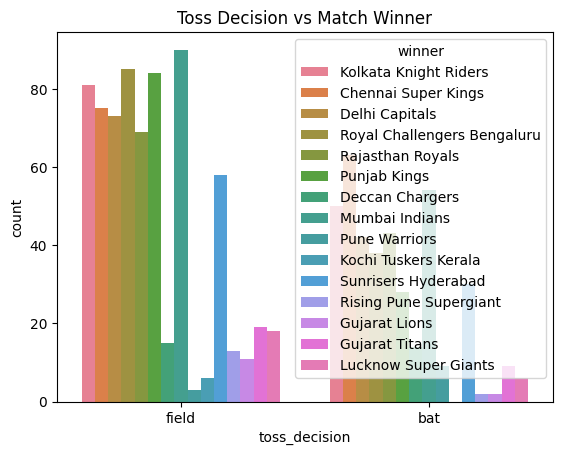

In [20]:
sns.countplot(x='toss_decision', hue='winner', data=df_matches)
plt.title("Toss Decision vs Match Winner")
plt.show()

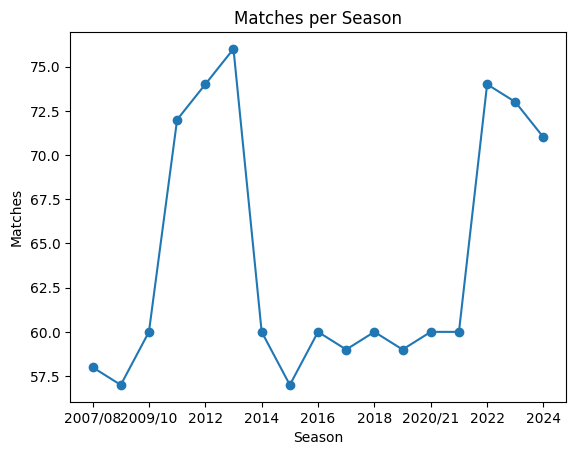

In [21]:
df_matches['season'].value_counts().sort_index().plot(kind='line', marker='o')
plt.title("Matches per Season")
plt.xlabel("Season")
plt.ylabel("Matches")
plt.show()

Feature Engineering

Team Strength

In [5]:
team_wins = df_matches['winner'].value_counts()
team_matches = df_matches['team1'].value_counts() + df_matches['team2'].value_counts()

team_win_rate = (team_wins / team_matches).fillna(0)

df_matches['team1_strength'] = df_matches['team1'].map(team_win_rate)
df_matches['team2_strength'] = df_matches['team2'].map(team_win_rate)

df_matches['strength_diff'] = df_matches['team1_strength'] - df_matches['team2_strength']

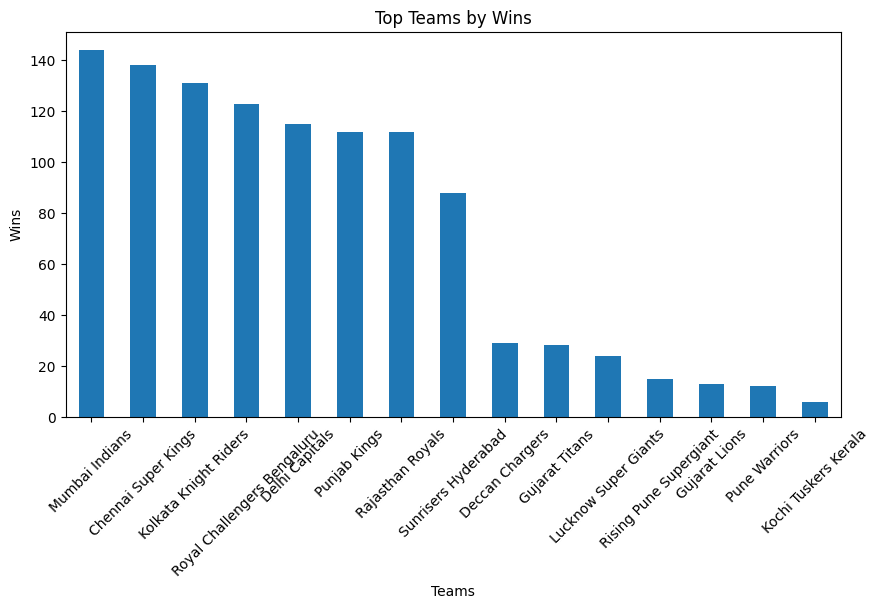

In [19]:
df_matches['winner'].value_counts().plot(kind='bar', figsize=(10,5))
plt.title("Top Teams by Wins")
plt.xlabel("Teams")
plt.ylabel("Wins")
plt.xticks(rotation=45)
plt.show()

Home Advantage

In [6]:
team_home_city = {
    'Mumbai Indians': 'Mumbai',
    'Chennai Super Kings': 'Chennai',
    'Kolkata Knight Riders': 'Kolkata',
    'Royal Challengers Bengaluru': 'Bangalore',
    'Delhi Capitals': 'Delhi',
    'Punjab Kings': 'Mohali',
    'Rajasthan Royals': 'Jaipur',
    'Sunrisers Hyderabad': 'Hyderabad',
    'Lucknow Super Giants': 'Lucknow',
    'Gujarat Titans': 'Ahmedabad'
}

df_matches['team1_home_city'] = df_matches['team1'].map(team_home_city)
df_matches['team2_home_city'] = df_matches['team2'].map(team_home_city)

df_matches['is_home_team1'] = (df_matches['team1_home_city'] == df_matches['city']).astype(int)
df_matches['is_home_team2'] = (df_matches['team2_home_city'] == df_matches['city']).astype(int)

df_matches = df_matches.drop(columns=['team1_home_city','team2_home_city'])

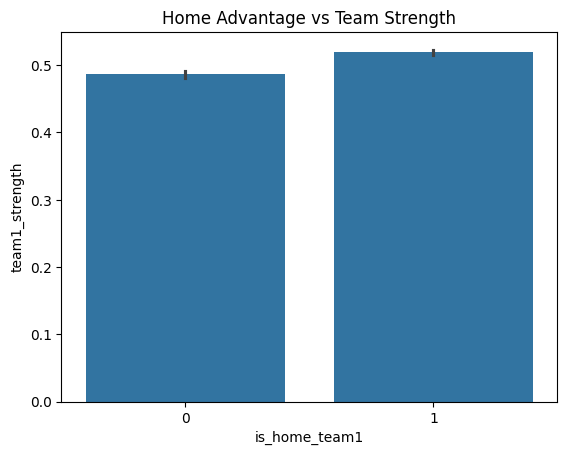

In [22]:
sns.barplot(x='is_home_team1', y='team1_strength', data=df_matches)
plt.title("Home Advantage vs Team Strength")
plt.show()

Venue Strength

In [7]:
venue_win = df_matches.groupby('venue')['winner'].value_counts(normalize=True)
venue_strength = venue_win.groupby(level=0).max()

df_matches['venue_strength'] = df_matches['venue'].map(venue_strength)

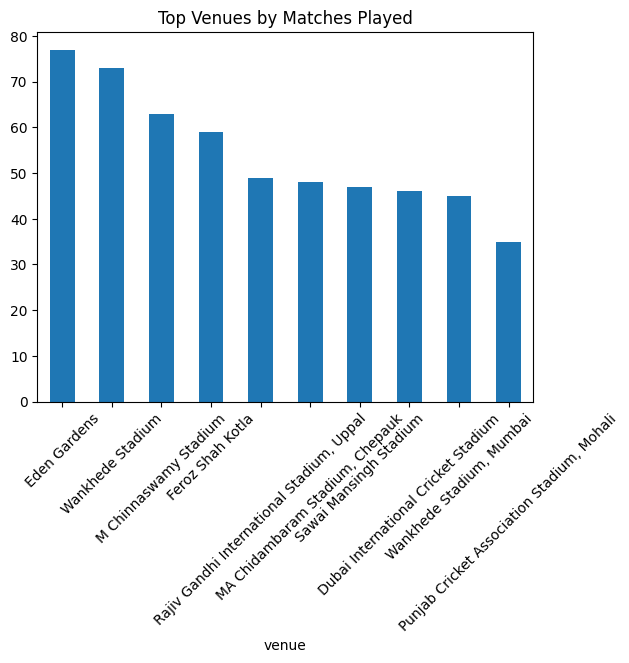

In [23]:
top_venues = df_matches['venue'].value_counts().head(10)
top_venues.plot(kind='bar')
plt.title("Top Venues by Matches Played")
plt.xticks(rotation=45)
plt.show()

Toss Advantage

In [8]:
df_matches['toss_advantage_team1'] = (df_matches['toss_winner'] == df_matches['team1']).astype(int)

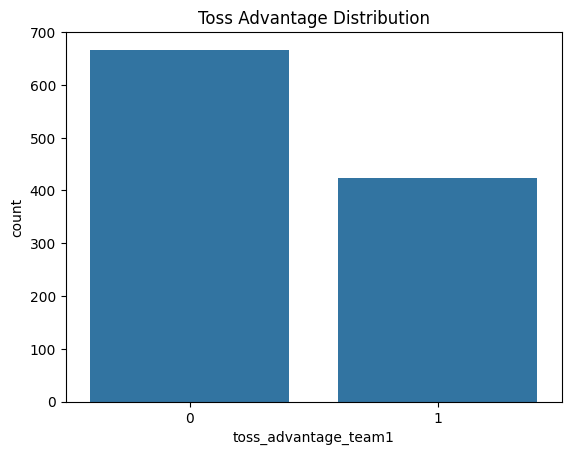

In [24]:
sns.countplot(x='toss_advantage_team1', data=df_matches)
plt.title("Toss Advantage Distribution")
plt.show()

Feature Selection

In [9]:
features = [
    'team1_strength',
    'team2_strength',
    'strength_diff',
    'venue_strength',
    'is_home_team1',
    'is_home_team2',
    'toss_advantage_team1'
]

X = df_matches[features]

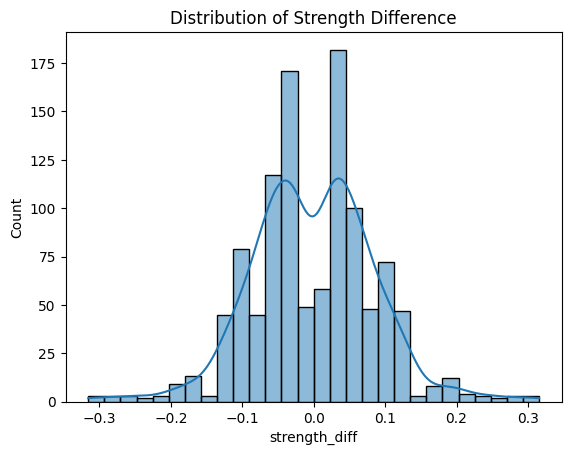

In [25]:
sns.histplot(df_matches['strength_diff'], kde=True)
plt.title("Distribution of Strength Difference")
plt.show()

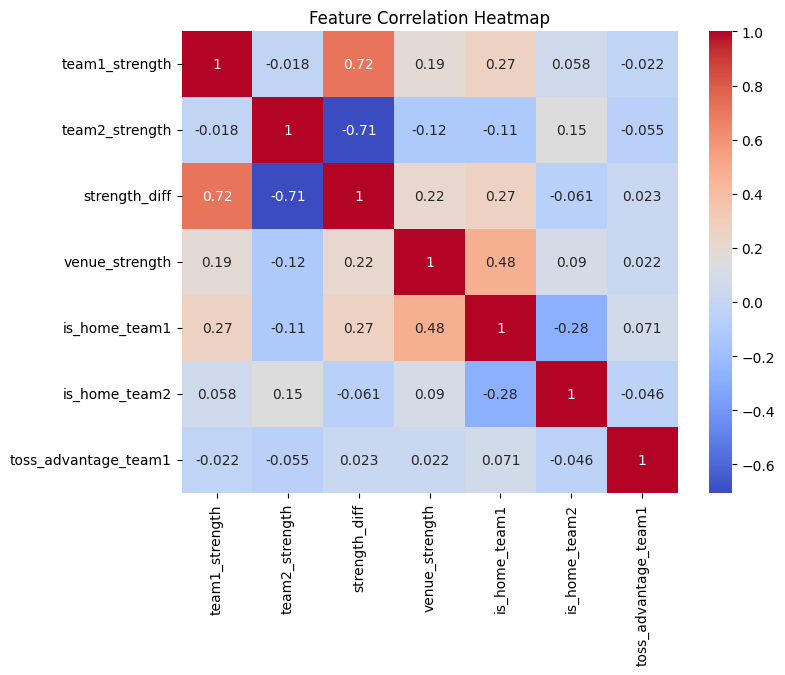

In [26]:
plt.figure(figsize=(8,6))
sns.heatmap(df_matches[[
    'team1_strength',
    'team2_strength',
    'strength_diff',
    'venue_strength',
    'is_home_team1',
    'is_home_team2',
    'toss_advantage_team1'
]].corr(), annot=True, cmap='coolwarm')

plt.title("Feature Correlation Heatmap")
plt.show()

Target Variable

In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y = le.fit_transform(df_matches['winner'])

Train-Test Split

In [11]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

Logistic Regression with scaling

In [12]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

lr = LogisticRegression(max_iter=1000)
lr.fit(X_train_scaled, y_train)

y_pred_lr = lr.predict(X_test_scaled)

Random Forest 

In [13]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    max_depth=8,
    min_samples_split=5,
    random_state=42
)

rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

XGBOOST

In [14]:
from xgboost import XGBClassifier

xgb = XGBClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=5,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='mlogloss'
)

xgb.fit(X_train, y_train)

y_pred_xgb = xgb.predict(X_test)


Evaluation - Accuracy

In [15]:
from sklearn.metrics import accuracy_score

print("Logistic Regression:", accuracy_score(y_test, y_pred_lr))
print("Random Forest:", accuracy_score(y_test, y_pred_rf))
print("XGBoost:", accuracy_score(y_test, y_pred_xgb))

Logistic Regression: 0.24770642201834864
Random Forest: 0.5504587155963303
XGBoost: 0.48623853211009177


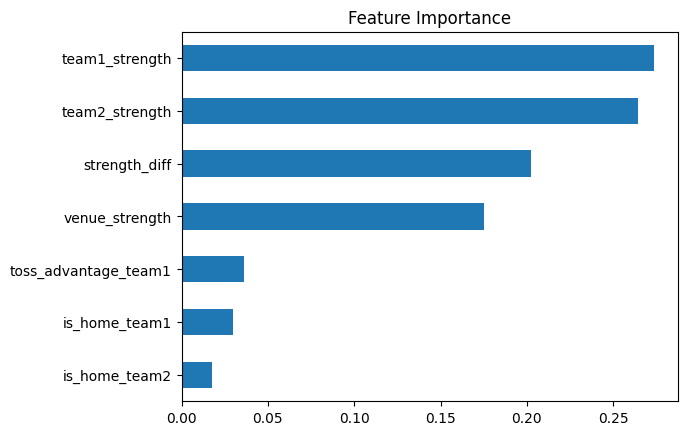

In [16]:
importance = pd.Series(rf.feature_importances_, index=X.columns)

importance.sort_values().plot(kind='barh')
plt.title("Feature Importance")
plt.show()

In [17]:
proba = xgb.predict_proba(X_test)

print("Sample Probabilities:")
print(proba[:5])

Sample Probabilities:
[[7.4094892e-01 3.0379030e-03 3.5745297e-02 1.1164263e-03 1.9842107e-03
  3.2813342e-03 4.0723947e-03 4.6342243e-03 2.7949948e-02 6.9856143e-04
  4.9971999e-03 2.3288922e-03 1.6339163e-03 5.3393850e-03 1.6223136e-01]
 [4.7066328e-03 1.1004829e-03 2.0913452e-01 1.1677631e-03 1.1501334e-03
  3.6638414e-03 6.0771601e-03 4.3551540e-03 7.3763317e-01 3.9820964e-04
  1.1416468e-02 5.3328155e-03 2.8856571e-03 7.6226299e-03 3.3553168e-03]
 [3.5612977e-01 1.1571556e-03 9.0470966e-03 2.5762399e-03 1.9226014e-03
  2.4754966e-03 3.6475311e-03 5.0696984e-02 6.2664924e-03 3.6753711e-04
  1.9709633e-03 4.8306063e-03 1.4214489e-03 5.5269343e-01 4.7967066e-03]
 [5.9078538e-01 5.4546917e-04 1.9796644e-03 4.3681732e-04 6.4800109e-04
  3.3840106e-04 3.8294157e-01 1.3395450e-03 8.8376421e-03 1.7875186e-04
  2.6249813e-03 3.0702564e-03 1.2311978e-03 4.2405534e-03 8.0180919e-04]
 [3.0217140e-03 1.2267880e-03 1.8558215e-02 1.2497238e-03 5.5375090e-04
  1.5015877e-03 1.2121053e-02 6.978910

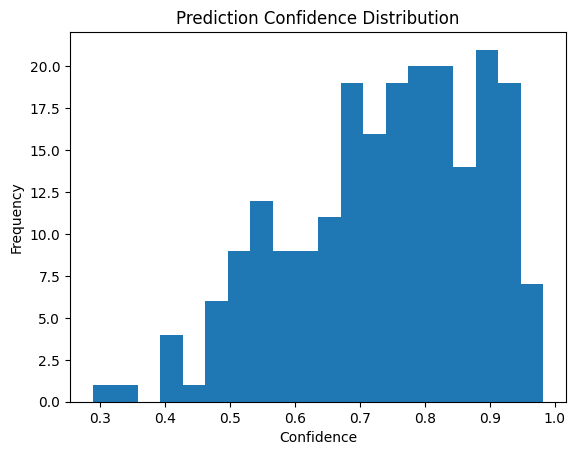

In [27]:
proba = xgb.predict_proba(X_test)

plt.hist(proba.max(axis=1), bins=20)
plt.title("Prediction Confidence Distribution")
plt.xlabel("Confidence")
plt.ylabel("Frequency")
plt.show()